# Retail Sales Data Analysis Project

## Project Objective

The goal of this project is to analyze a retail sales dataset to understand sales performance, product category performance, and regional performance.

This project includes data loading, data cleaning, exploratory data analysis, visualization, and business insights.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the Dataset

In this section, I load the retail sales dataset using pandas and display the first few rows.

In [36]:
df = pd.read_csv(r"C:\Users\bilal\Downloads\retail_sales.csv")

df.head()

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East


## 2. Dataset Overview

In this section, I check the dataset size, column names, data types, missing values, and date range.

In [37]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Number of rows: 1825
Number of columns: 6

Column names:
Index(['Date', 'Category', 'Sales', 'Quantity', 'Profit', 'Region'], dtype='str')

Data types:
Date            str
Category        str
Sales       float64
Quantity    float64
Profit      float64
Region          str
dtype: object

Missing values:
Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64


In [38]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

Start date: 2023-01-01 00:00:00
End date: 2023-12-31 00:00:00


The dataset overview shows the number of records and variables in the dataset.  
It also shows the column data types, missing values, and the time period covered by the sales data.

## 3. Data Cleaning

In this section, I clean the dataset by handling missing values, fixing data types, removing duplicates, and preparing the data for analysis.

In [39]:
df_clean = df.copy()

df_clean.columns = df_clean.columns.str.strip()

print("Original dataset shape:", df_clean.shape)

Original dataset shape: (1825, 6)


In [40]:
missing_table = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": (df_clean.isnull().sum() / len(df_clean)) * 100
})

missing_table

,Missing Values,Missing Percentage
Date,0,0.000000
Category,4,0.219178
Sales,2,0.109589
Quantity,5,0.273973
Profit,0,0.000000
Region,5,0.273973


In [41]:
important_columns = ["Date", "Category", "Sales", "Quantity", "Profit", "Region"]

df_clean = df_clean.dropna(subset=important_columns)

print("Shape after removing missing values:", df_clean.shape)

Shape after removing missing values: (1810, 6)


In [42]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

numeric_columns = ["Sales", "Quantity", "Profit"]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print(df_clean.dtypes)

Date        datetime64[us]
Category               str
Sales              float64
Quantity           float64
Profit             float64
Region                 str
dtype: object


In [43]:
df_clean = df_clean.dropna()

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Date        0
Category    0
Sales       0
Quantity    0
Profit      0
Region      0
dtype: int64


In [44]:
print("Duplicates before removing:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()

print("Duplicates after removing:", df_clean.duplicated().sum())

Duplicates before removing: 0
Duplicates after removing: 0


## 4. Feature Engineering

In this section, I create new useful columns from the existing data to support deeper analysis.

In [45]:
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Month_Name"] = df_clean["Date"].dt.month_name()
df_clean["Day"] = df_clean["Date"].dt.day
df_clean["Day_of_Week"] = df_clean["Date"].dt.day_name()

df_clean.head()

,Date,Category,Sales,Quantity,Profit,Region,Year,Month,Month_Name,Day,Day_of_Week
0,2023-01-01,Electronics,1149.014246,11.0,383.664245,North,2023,1,January,1,Sunday
1,2023-01-01,Clothing,958.520710,7.0,224.054049,East,2023,1,January,1,Sunday
2,2023-01-01,Home Goods,1473.763845,2.0,466.593090,South,2023,1,January,1,Sunday
3,2023-01-01,Sports,1230.230419,6.0,123.310460,West,2023,1,January,1,Sunday
4,2023-01-01,NaN?,828.585950,12.0,88.591355,East,2023,1,January,1,Sunday


In [46]:
df_clean["Sales_per_Item"] = df_clean["Sales"] / df_clean["Quantity"]
df_clean["Profit_Margin"] = df_clean["Profit"] / df_clean["Sales"]

df_clean.head()

,Date,Category,Sales,Quantity,Profit,Region,Year,Month,Month_Name,Day,Day_of_Week,Sales_per_Item,Profit_Margin
0,2023-01-01,Electronics,1149.014246,11.0,383.664245,North,2023,1,January,1,Sunday,104.455841,0.333907
1,2023-01-01,Clothing,958.520710,7.0,224.054049,East,2023,1,January,1,Sunday,136.931530,0.233750
2,2023-01-01,Home Goods,1473.763845,2.0,466.593090,South,2023,1,January,1,Sunday,736.881922,0.316600
3,2023-01-01,Sports,1230.230419,6.0,123.310460,West,2023,1,January,1,Sunday,205.038403,0.100234
4,2023-01-01,NaN?,828.585950,12.0,88.591355,East,2023,1,January,1,Sunday,69.048829,0.106919


In [47]:
def sales_level(sales):
    if sales < 100:
        return "Low"
    elif sales < 500:
        return "Medium"
    else:
        return "High"

df_clean["Sales_Level"] = df_clean["Sales"].apply(sales_level)

df_clean[["Sales", "Sales_Level"]].head()

,Sales,Sales_Level
0,1149.014246,High
1,958.520710,High
2,1473.763845,High
3,1230.230419,High
4,828.585950,High


In [48]:
def profit_status(profit):
    if profit > 0:
        return "Profit"
    elif profit < 0:
        return "Loss"
    else:
        return "Break-even"

df_clean["Profit_Status"] = df_clean["Profit"].apply(profit_status)

df_clean[["Profit", "Profit_Status"]].head()

,Profit,Profit_Status
0,383.664245,Profit
1,224.054049,Profit
2,466.593090,Profit
3,123.310460,Profit
4,88.591355,Profit


## 5. Final Cleaned Dataset Check

In this section, I check the final cleaned dataset before starting the analysis.

In [49]:
print("Final shape:", df_clean.shape)

print("\nFinal data types:")
print(df_clean.dtypes)

print("\nFinal missing values:")
print(df_clean.isnull().sum())

print("\nFinal duplicates:")
print(df_clean.duplicated().sum())

Final shape: (1810, 15)

Final data types:
Date              datetime64[us]
Category                     str
Sales                    float64
Quantity                 float64
Profit                   float64
Region                       str
Year                       int32
Month                      int32
Month_Name                   str
Day                        int32
Day_of_Week                  str
Sales_per_Item           float64
Profit_Margin            float64
Sales_Level                  str
Profit_Status                str
dtype: object

Final missing values:
Date              0
Category          0
Sales             0
Quantity          0
Profit            0
Region            0
Year              0
Month             0
Month_Name        0
Day               0
Day_of_Week       0
Sales_per_Item    0
Profit_Margin     2
Sales_Level       0
Profit_Status     0
dtype: int64

Final duplicates:
0


## 6. Exploratory Data Analysis

In this section, I analyze the cleaned dataset to answer business questions about sales performance, product categories, and regional performance.

### A. Sales Performance

In this section, I analyze sales over time and identify the strongest sales days.

In [50]:
monthly_sales = df_clean.groupby(["Year", "Month"])["Sales"].sum().reset_index()

monthly_sales["Year_Month"] = (
    monthly_sales["Year"].astype(str) + "-" + monthly_sales["Month"].astype(str)
)

monthly_sales

,Year,Month,Sales,Year_Month
0,2023,1,134435.595627,2023-1
1,2023,2,132215.411776,2023-2
2,2023,3,145321.200626,2023-3
3,2023,4,138160.991209,2023-4
4,2023,5,150774.977103,2023-5
5,2023,6,152605.749860,2023-6
6,2023,7,162111.115687,2023-7
7,2023,8,148020.452251,2023-8
8,2023,9,153094.700793,2023-9
9,2023,10,151272.280840,2023-10


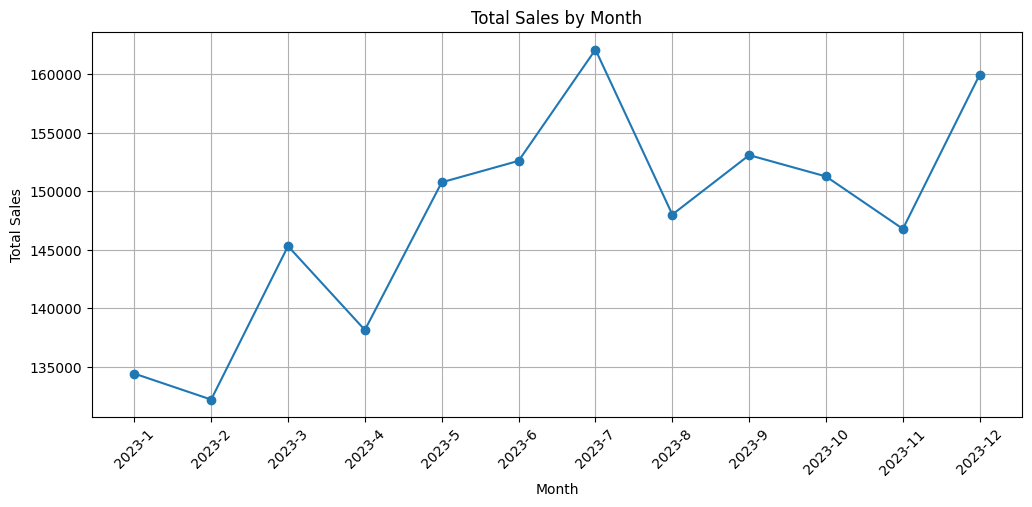

In [51]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales["Year_Month"], monthly_sales["Sales"], marker="o")

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

The line chart shows the monthly sales trend over time.  
This helps identify whether sales are increasing, decreasing, or changing seasonally.

In [52]:
weekday_sales = df_clean.groupby("Day_of_Week")["Sales"].sum().sort_values(ascending=False)

weekday_sales

Day_of_Week
Friday       262035.111668
Sunday       258460.913648
Monday       253145.486589
Saturday     252147.200714
Tuesday      251026.454771
Thursday     250167.338860
Wednesday    247804.390341
Name: Sales, dtype: float64

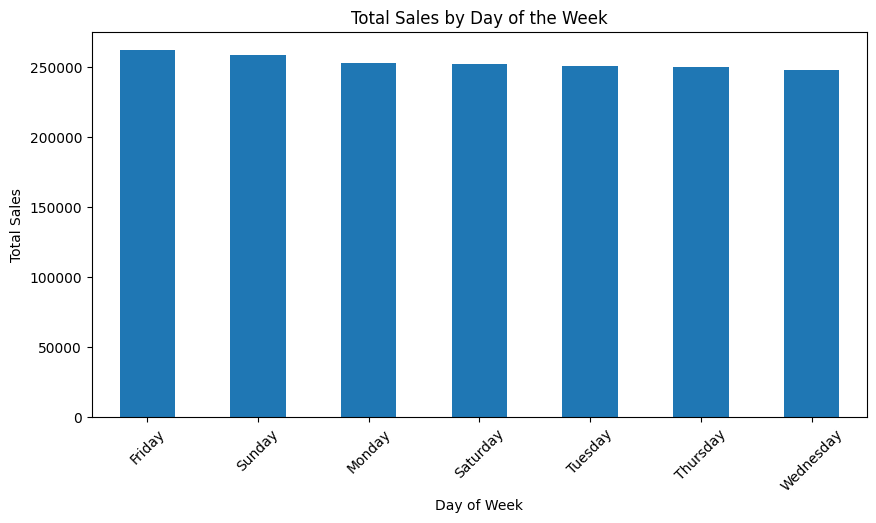

In [53]:
plt.figure(figsize=(10, 5))

weekday_sales.plot(kind="bar")

plt.title("Total Sales by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [54]:
print("Day with highest sales:", weekday_sales.idxmax())
print("Highest sales amount:", weekday_sales.max())

Day with highest sales: Friday
Highest sales amount: 262035.11166848912


### B. Product Insights

In this section, I analyze product categories to identify which categories generate the most revenue and which categories have the highest quantity sold.

In [55]:
category_sales = df_clean.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Books          370971.872558
Electronics    364090.406288
Clothing       350981.822773
Home Goods     344634.290152
Sports         341349.880348
Null             1106.847949
NaN?              828.585950
Nan               823.190573
Name: Sales, dtype: float64

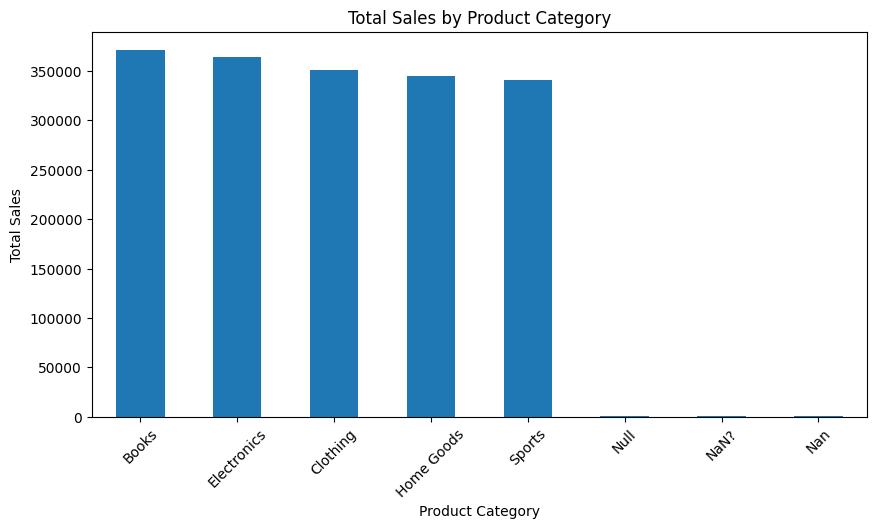

In [56]:
plt.figure(figsize=(10, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [57]:
print("Category with highest revenue:", category_sales.idxmax())
print("Highest category sales:", category_sales.max())

Category with highest revenue: Books
Highest category sales: 370971.872557938


In [58]:
category_quantity = df_clean.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

category_quantity

Category
Home Goods     3755.0
Books          3737.0
Clothing       3641.0
Electronics    3576.0
Sports         3470.0
NaN?             12.0
Null             11.0
Nan               4.0
Name: Quantity, dtype: float64

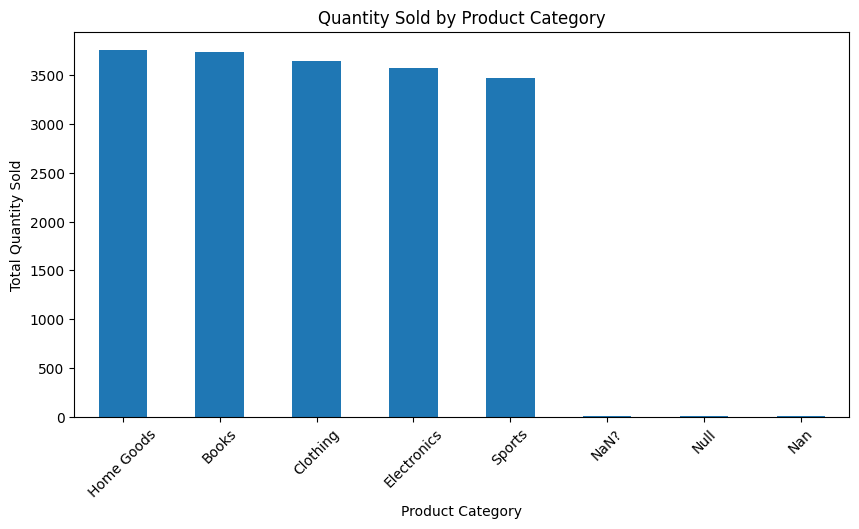

In [59]:
plt.figure(figsize=(10, 5))

category_quantity.plot(kind="bar")

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)

plt.show()

In [60]:
print("Category with highest quantity sold:", category_quantity.idxmax())
print("Highest quantity sold:", category_quantity.max())

Category with highest quantity sold: Home Goods
Highest quantity sold: 3755.0


The product category analysis shows which categories contribute the most to total sales and which categories sell the highest number of units.

Sales analysis focuses on revenue, while quantity analysis focuses on sales volume. A category can have high revenue because of high prices, even if the number of units sold is not the highest.

### C. Regional Performance

In this section, I compare sales and profit across regions to identify the strongest and weakest performing regions.

In [61]:
region_sales = df_clean.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
West     469452.674788
South    467014.789395
North    445618.542850
East     390984.178771
Nan        1716.710787
Name: Sales, dtype: float64

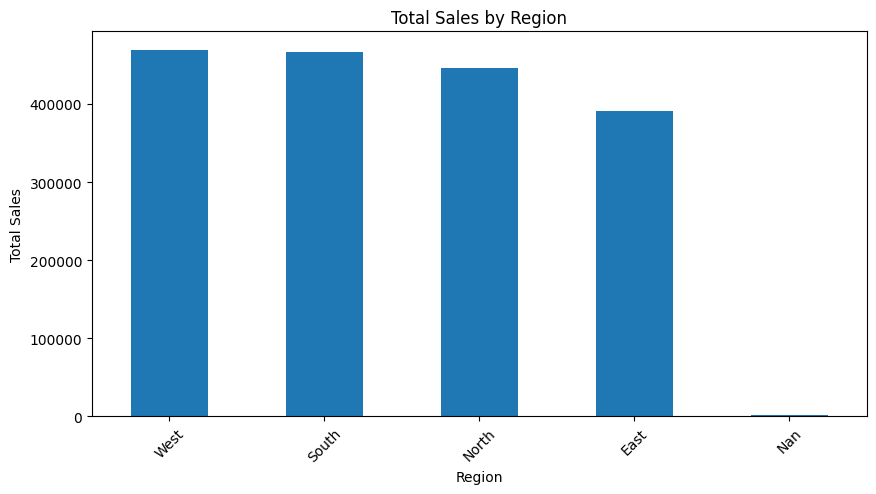

In [62]:
plt.figure(figsize=(10, 5))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [63]:
print("Region with highest sales:", region_sales.idxmax())
print("Highest regional sales:", region_sales.max())

Region with highest sales: West
Highest regional sales: 469452.674787993


In [64]:
region_profit = df_clean.groupby("Region")["Profit"].sum().sort_values(ascending=False)

region_profit

Region
West     122329.449142
South    117569.442029
North    110775.161869
East      98360.225010
Nan         545.617726
Name: Profit, dtype: float64

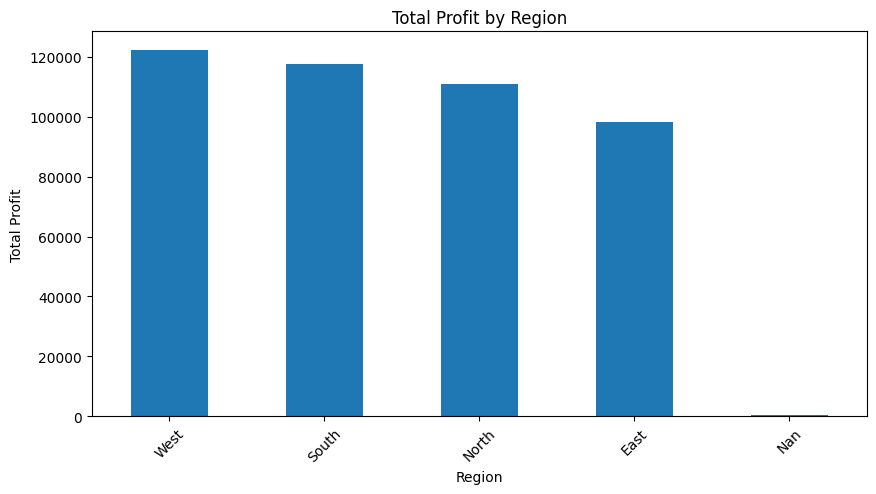

In [65]:
plt.figure(figsize=(10, 5))

region_profit.plot(kind="bar")

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)

plt.show()

In [66]:
print("Region with highest profit:", region_profit.idxmax())
print("Highest regional profit:", region_profit.max())

Region with highest profit: West
Highest regional profit: 122329.44914243028


The regional analysis compares sales and profit by region. This helps identify which regions generate the highest revenue and which regions are more profitable.

A region with high sales is not always the most profitable region, so both sales and profit should be analyzed together.

## 7. Summary KPIs

In this section, I calculate the main business metrics from the cleaned dataset.

In [67]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_quantity = df_clean["Quantity"].sum()
average_order_value = df_clean["Sales"].mean()
average_profit_margin = df_clean["Profit_Margin"].mean()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(average_order_value, 2))
print("Average Profit Margin:", round(average_profit_margin, 4))

Total Sales: 1774786.9
Total Profit: 449579.9
Total Quantity Sold: 18206.0
Average Order Value: 980.55
Average Profit Margin: inf


In [68]:
kpi_table = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Quantity Sold",
        "Average Order Value",
        "Average Profit Margin"
    ],
    "Value": [
        round(total_sales, 2),
        round(total_profit, 2),
        total_quantity,
        round(average_order_value, 2),
        round(average_profit_margin, 4)
    ]
})

kpi_table

,Metric,Value
0,Total Sales,1774786.90
1,Total Profit,449579.90
2,Total Quantity Sold,18206.00
3,Average Order Value,980.55
4,Average Profit Margin,inf


## 8. Key Insights

Based on the exploratory data analysis, the main findings are summarized below.

In [69]:
top_month = monthly_sales.loc[monthly_sales["Sales"].idxmax(), "Year_Month"]
top_month_sales = monthly_sales["Sales"].max()

top_day = weekday_sales.idxmax()
top_day_sales = weekday_sales.max()

top_category_revenue = category_sales.idxmax()
top_category_revenue_value = category_sales.max()

top_category_quantity = category_quantity.idxmax()
top_category_quantity_value = category_quantity.max()

top_region_sales = region_sales.idxmax()
top_region_sales_value = region_sales.max()

top_region_profit = region_profit.idxmax()
top_region_profit_value = region_profit.max()

print("Top sales month:", top_month, "with sales of", round(top_month_sales, 2))
print("Best sales day:", top_day, "with sales of", round(top_day_sales, 2))
print("Top revenue category:", top_category_revenue, "with sales of", round(top_category_revenue_value, 2))
print("Top quantity category:", top_category_quantity, "with quantity of", top_category_quantity_value)
print("Top sales region:", top_region_sales, "with sales of", round(top_region_sales_value, 2))
print("Top profit region:", top_region_profit, "with profit of", round(top_region_profit_value, 2))

Top sales month: 2023-7 with sales of 162111.12
Best sales day: Friday with sales of 262035.11
Top revenue category: Books with sales of 370971.87
Top quantity category: Home Goods with quantity of 3755.0
Top sales region: West with sales of 469452.67
Top profit region: West with profit of 122329.45


### Main Findings

- The highest sales month was **[write month here]**.
- The day with the highest sales was **[write day here]**.
- The product category with the highest revenue was **[write category here]**.
- The product category with the highest quantity sold was **[write category here]**.
- The region with the highest sales was **[write region here]**.
- The region with the highest profit was **[write region here]**.

These findings help identify the strongest time periods, product categories, and regions in the retail sales dataset.

## 9. Recommendations

Based on the analysis, the following business recommendations can be made:

1. Focus marketing efforts on the best-performing product category because it generates the highest revenue.
2. Monitor the category with the highest quantity sold to ensure enough inventory is available.
3. Study the top-performing region to understand why it performs better than other regions.
4. Investigate lower-performing regions to identify possible issues in demand, pricing, or operations.
5. Track monthly sales trends to prepare promotions and stock before high-sales periods.
6. Analyze both sales and profit together because high revenue does not always mean high profitability.

## 10. Limitations

Some business questions could not be answered because the dataset does not include customer-level or transaction-level details such as customer ID, gender, age, payment method, discount, store name, or product name.

Because of this, the analysis focuses mainly on sales performance, product category performance, and regional performance.

## 11. Save Cleaned Dataset

In this section, I save the cleaned dataset as a CSV file so it can be used later for dashboard creation or further analysis.

In [73]:
import os

project_folder = r"C:\Users\bilal\Desktop\Retail-Sales-Analysis"

os.makedirs(project_folder, exist_ok=True)

df_clean.to_csv(project_folder + r"\cleaned_retail_sales.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
